In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\machine learning project python\Telecom_Dataset (1).csv")
df.head()

,Customer_ID,Tenure_Months,Monthly_Spend,Avg_Data_Usage_GB,Usage_Hours,Complaints_Last_6M,Payment_Delay_Days,Support_Calls,Contract_Type,Plan_Type,Auto_Pay,Discount_Received_%,Internet_Speed_Mbps,Region,Churn
0,1,52,958.66,14.60,101.1,1,5.8,3,2-Year,Standard,1,20,100,South,0
1,2,15,963.19,11.08,104.1,0,1.7,1,Monthly,Basic,1,0,200,West,0
2,3,61,1311.60,22.14,111.2,2,0.6,0,Annual,Standard,0,5,100,West,0
3,4,21,648.23,22.03,76.3,2,0.6,3,Annual,Basic,1,5,50,South,0
4,5,24,735.69,18.35,135.8,2,4.4,2,Annual,Standard,1,0,100,West,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1000 non-null   int64  
 1   Tenure_Months        1000 non-null   int64  
 2   Monthly_Spend        1000 non-null   float64
 3   Avg_Data_Usage_GB    1000 non-null   float64
 4   Usage_Hours          1000 non-null   float64
 5   Complaints_Last_6M   1000 non-null   int64  
 6   Payment_Delay_Days   1000 non-null   float64
 7   Support_Calls        1000 non-null   int64  
 8   Contract_Type        1000 non-null   object 
 9   Plan_Type            1000 non-null   object 
 10  Auto_Pay             1000 non-null   int64  
 11  Discount_Received_%  1000 non-null   int64  
 12  Internet_Speed_Mbps  1000 non-null   int64  
 13  Region               1000 non-null   object 
 14  Churn                1000 non-null   int64  
dtypes: float64(4), int64(8), object(3)
memo

In [4]:
df.columns

Index(['Customer_ID', 'Tenure_Months', 'Monthly_Spend', 'Avg_Data_Usage_GB',
       'Usage_Hours', 'Complaints_Last_6M', 'Payment_Delay_Days',
       'Support_Calls', 'Contract_Type', 'Plan_Type', 'Auto_Pay',
       'Discount_Received_%', 'Internet_Speed_Mbps', 'Region', 'Churn'],
      dtype='object')

In [5]:
# Function to remove outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower) & (df[column] <= upper)]

In [6]:
df_clean = df.copy()

for col in ['Monthly_Spend', 'Tenure_Months', 'Avg_Data_Usage_GB',
            'Usage_Hours', 'Payment_Delay_Days', 'Internet_Speed_Mbps']:
    
    df_clean = remove_outliers(df_clean, col)

Churn                  1.000000
Complaints_Last_6M     0.194531
Payment_Delay_Days     0.047299
Internet_Speed_Mbps    0.033137
Monthly_Spend          0.021784
Support_Calls          0.016676
Avg_Data_Usage_GB      0.015561
Usage_Hours            0.010958
Discount_Received_%   -0.023124
Customer_ID           -0.035479
Auto_Pay              -0.084630
Tenure_Months         -0.219521
Name: Churn, dtype: float64


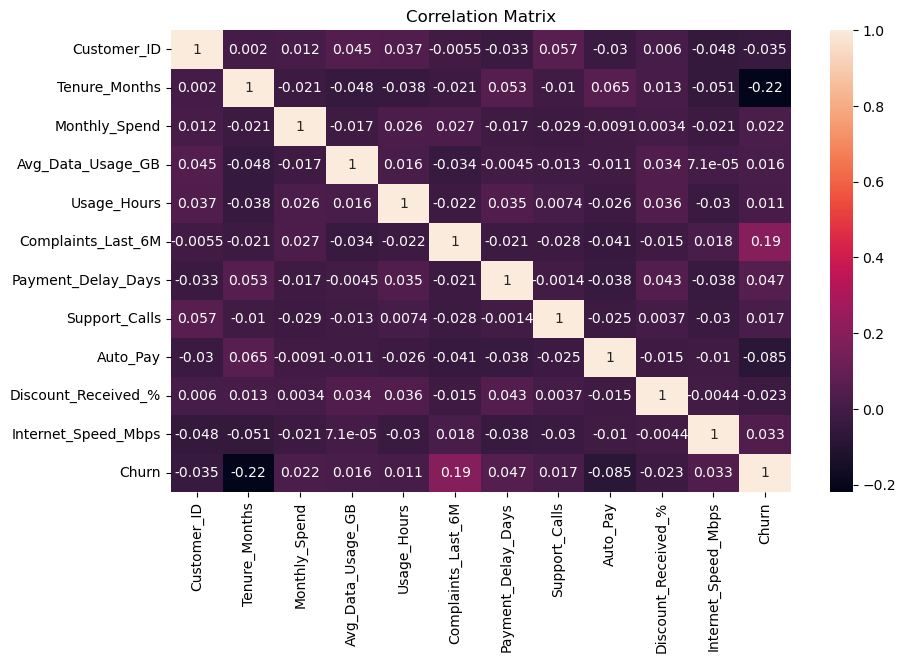

In [7]:
corr = df_clean.select_dtypes(include=['number']).corr()

print(corr['Churn'].sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

In [8]:
churn_rate = df['Churn'].mean() * 100
print("Overall Churn Rate:", churn_rate, "%")

Overall Churn Rate: 8.799999999999999 %


In [9]:
print(df['Churn'].value_counts())

Churn
0    912
1     88
Name: count, dtype: int64


In [10]:
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    91.2
1     8.8
Name: proportion, dtype: float64


In [11]:
print(df.describe())

       Customer_ID  Tenure_Months  Monthly_Spend  Avg_Data_Usage_GB  \
count  1000.000000    1000.000000    1000.000000         1000.00000   
mean    500.500000      35.489000     898.912650           14.91278   
std     288.819436      20.709485     243.290905            5.93042   
min       1.000000       1.000000     300.000000            1.00000   
25%     250.750000      17.000000     728.005000           10.83500   
50%     500.500000      35.000000     906.870000           14.85500   
75%     750.250000      54.000000    1058.452500           18.99500   
max    1000.000000      71.000000    1641.250000           33.37000   

       Usage_Hours  Complaints_Last_6M  Payment_Delay_Days  Support_Calls  \
count  1000.000000         1000.000000         1000.000000     1000.00000   
mean     99.792200            1.175000            2.804700        2.00000   
std      29.659595            1.043774            2.782871        1.37982   
min      20.000000            0.000000            0.

Payment_bin
(-0.001, 0.6]    0.083744
(0.6, 1.5]       0.057692
(1.5, 2.5]       0.091837
(2.5, 4.4]       0.117949
(4.4, 20.5]      0.090909
Name: Churn, dtype: float64


C:\Users\shwet\AppData\Local\Temp\ipykernel_11292\3947879453.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_payment = df.groupby('Payment_bin')['Churn'].mean()


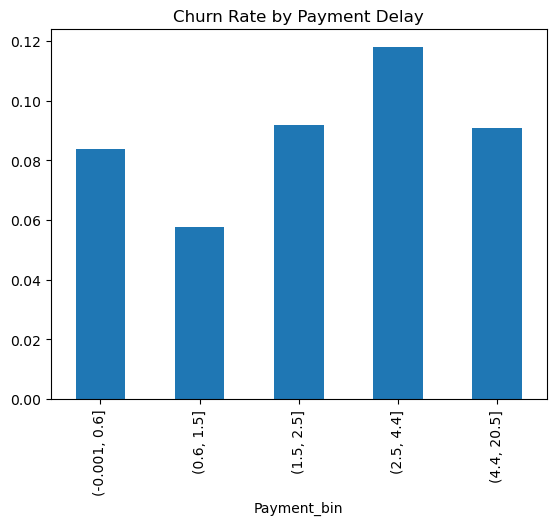

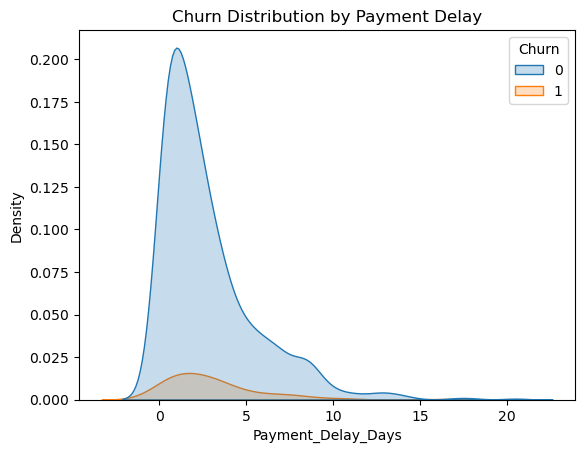

In [12]:
#Churn Rate by Payment Delay
df['Payment_bin'] = pd.qcut(df['Payment_Delay_Days'], 5)

churn_payment = df.groupby('Payment_bin')['Churn'].mean()
print(churn_payment)

churn_payment.plot(kind='bar')
plt.title('Churn Rate by Payment Delay')
plt.show()
plt.figure()
sns.kdeplot(data=df, x='Payment_Delay_Days', hue='Churn', fill=True)
plt.title('Churn Distribution by Payment Delay')
plt.show()

Complaints_Last_6M
0    0.048110
1    0.067708
2    0.110599
3    0.170732
4    0.368421
5    0.428571
Name: Churn, dtype: float64


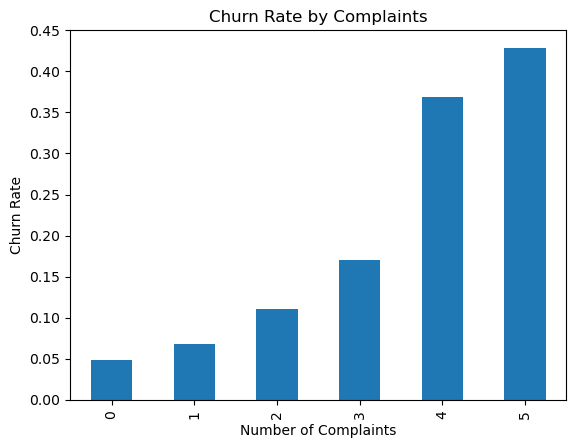

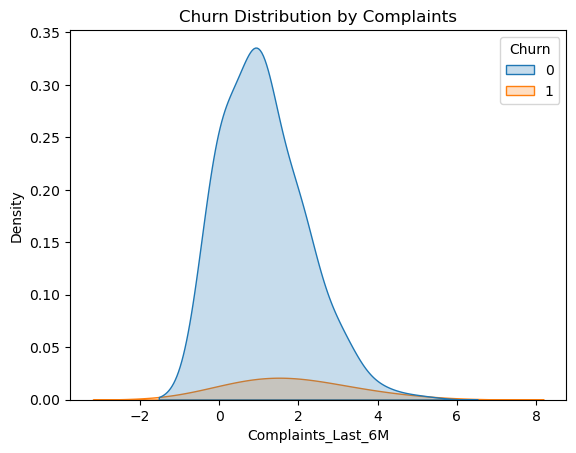

In [13]:
#Churn Rate by Complaints
churn_complaints = df.groupby('Complaints_Last_6M')['Churn'].mean()
print(churn_complaints)

churn_complaints.plot(kind='bar')
plt.title('Churn Rate by Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Churn Rate')
plt.show()
plt.figure()
sns.kdeplot(data=df, x='Complaints_Last_6M', hue='Churn', fill=True, bw_adjust=2)
plt.title('Churn Distribution by Complaints')
plt.show()

Internet_Speed_Mbps
25     0.075710
50     0.102113
100    0.063492
200    0.129252
Name: Churn, dtype: float64


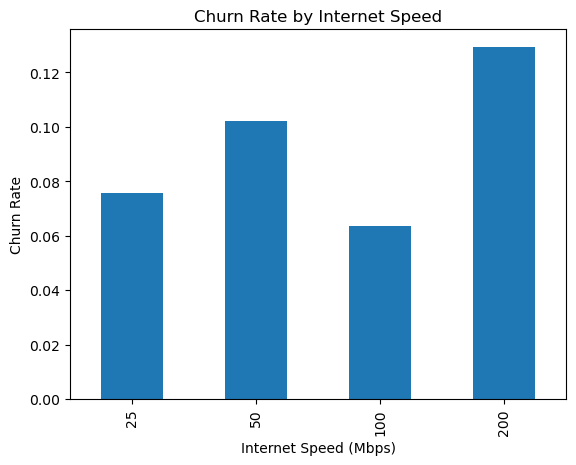

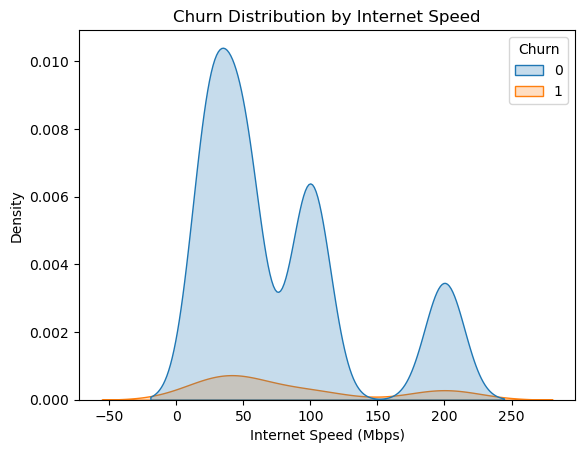

In [14]:
#Churn Rate by Internet Speed
churn_internet = df.groupby('Internet_Speed_Mbps')['Churn'].mean()
print(churn_internet)
churn_internet.plot(kind='bar')
plt.title('Churn Rate by Internet Speed')
plt.xlabel('Internet Speed (Mbps)')
plt.ylabel('Churn Rate')
plt.show()
plt.figure()

sns.kdeplot(data=df, x='Internet_Speed_Mbps', hue='Churn', fill=True)

plt.title('Churn Distribution by Internet Speed')
plt.xlabel('Internet Speed (Mbps)')
plt.ylabel('Density')

plt.show()

C:\Users\shwet\AppData\Local\Temp\ipykernel_11292\165320372.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_spend = df.groupby('Spend_bin')['Churn'].mean()


Spend_bin
(299.999, 689.962]     0.080
(689.962, 835.79]      0.080
(835.79, 967.132]      0.090
(967.132, 1100.914]    0.095
(1100.914, 1641.25]    0.095
Name: Churn, dtype: float64


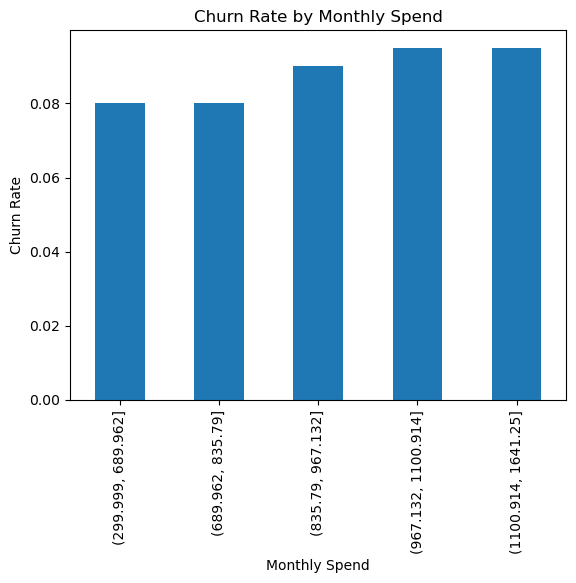

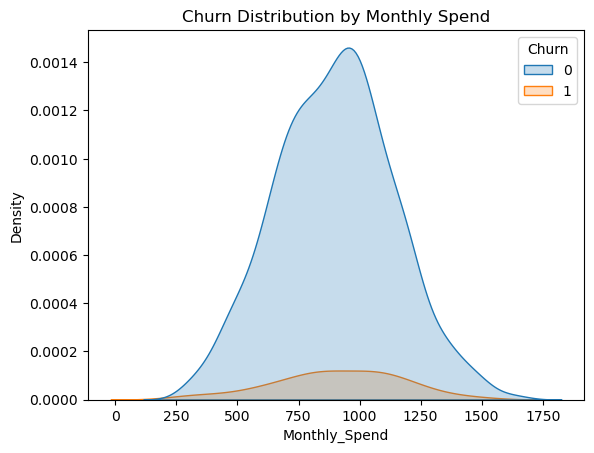

In [15]:
#Churn Rate by Monthly Spend
df['Spend_bin'] = pd.qcut(df['Monthly_Spend'], 5)
churn_spend = df.groupby('Spend_bin')['Churn'].mean()
print(churn_spend)
churn_spend.plot(kind='bar')
plt.title('Churn Rate by Monthly Spend')
plt.xlabel('Monthly Spend')
plt.ylabel('Churn Rate')
plt.show()
plt.figure()
sns.kdeplot(data=df, x='Monthly_Spend', hue='Churn', fill=True)
plt.title('Churn Distribution by Monthly Spend')
plt.show()

C:\Users\shwet\AppData\Local\Temp\ipykernel_11292\798031138.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_tenure = df.groupby('Tenure_bin')['Churn'].mean()


Tenure_bin
(0.999, 14.0]    0.194175
(14.0, 28.0]     0.137755
(28.0, 43.0]     0.044335
(43.0, 57.0]     0.035533
(57.0, 71.0]     0.025253
Name: Churn, dtype: float64


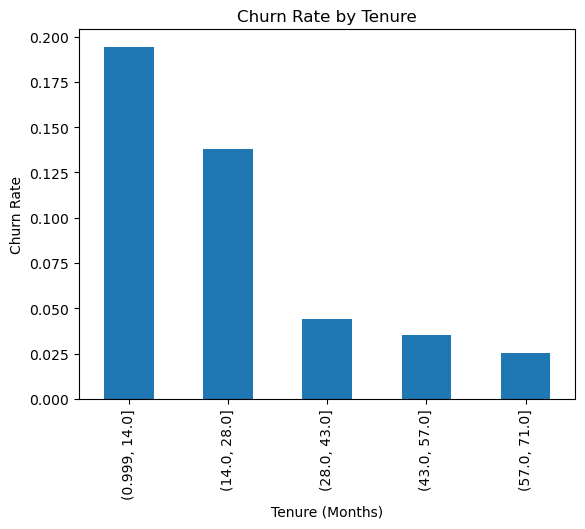

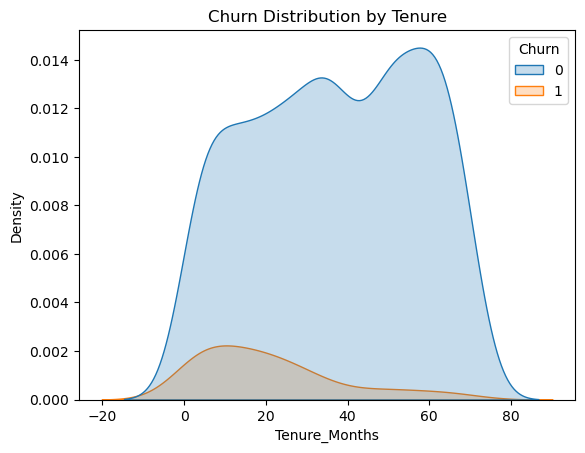

In [16]:
#Churn Rate by Tenure
df['Tenure_bin'] = pd.qcut(df['Tenure_Months'], 5)
churn_tenure = df.groupby('Tenure_bin')['Churn'].mean()
print(churn_tenure)
churn_tenure.plot(kind='bar')
plt.title('Churn Rate by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Churn Rate')
plt.show()
plt.figure()
sns.kdeplot(data=df, x='Tenure_Months', hue='Churn', fill=True)
plt.title('Churn Distribution by Tenure')
plt.show()

Support_Calls
0    0.061538
1    0.100372
2    0.088968
3    0.069364
4    0.138614
5    0.029412
6    0.111111
7    0.000000
8    0.000000
Name: Churn, dtype: float64


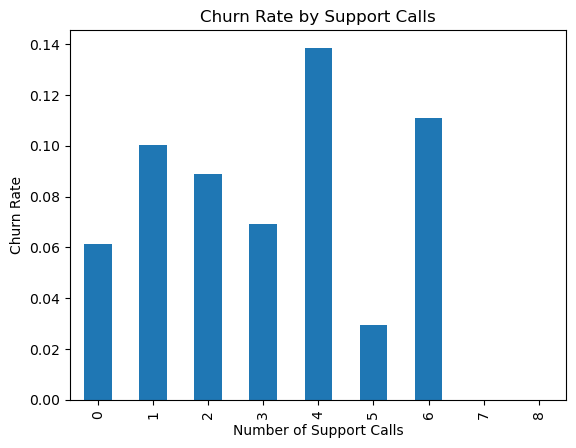

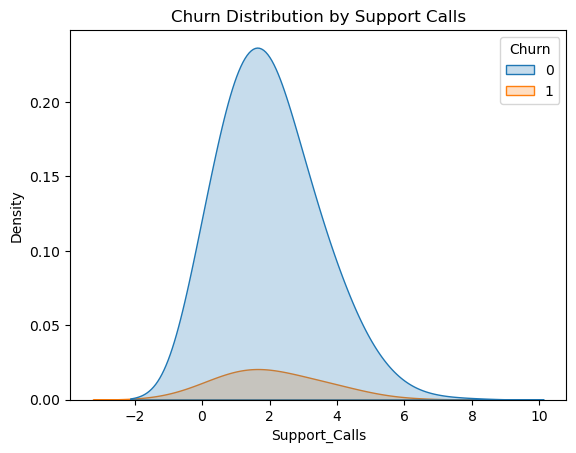

In [17]:
#Churn Rate by Support Calls
churn_support = df.groupby('Support_Calls')['Churn'].mean()
print(churn_support)
churn_support.plot(kind='bar')
plt.title('Churn Rate by Support Calls')
plt.xlabel('Number of Support Calls')
plt.ylabel('Churn Rate')
plt.show()
plt.figure()
sns.kdeplot(data=df, x='Support_Calls', hue='Churn', fill=True, bw_adjust=2)
plt.title('Churn Distribution by Support Calls')
plt.show()


Contract_Type
2-Year     0.043062
Annual     0.050542
Monthly    0.126459
Name: Churn, dtype: float64


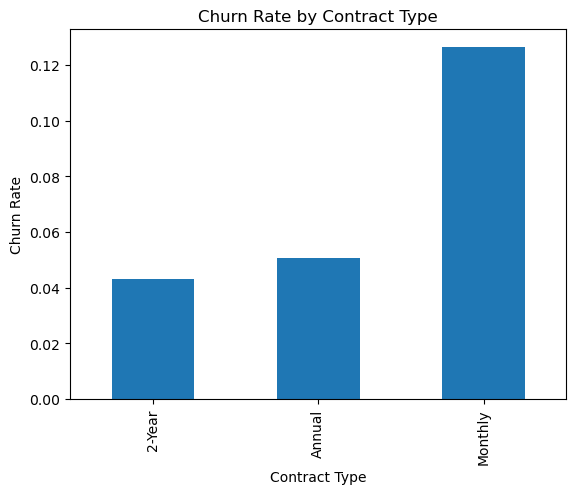

In [18]:
#Churn Rate by Contract Type
churn_contract = df.groupby('Contract_Type')['Churn'].mean()
print(churn_contract)
churn_contract.plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.show()




Auto_Pay
0    0.113861
1    0.070470
Name: Churn, dtype: float64


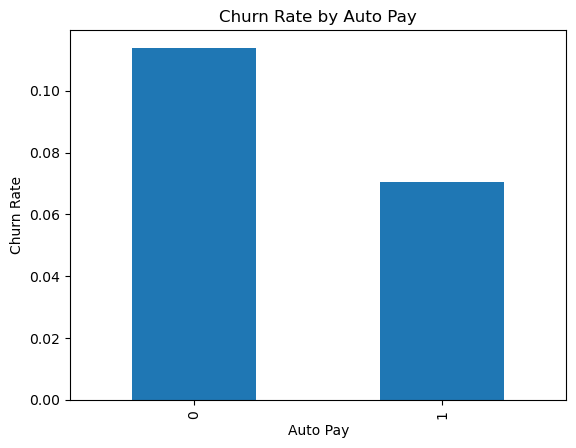

In [19]:
#Churn Rate by Auto Pay
churn_autopay = df.groupby('Auto_Pay')['Churn'].mean()
print(churn_autopay)
churn_autopay.plot(kind='bar')
plt.title('Churn Rate by Auto Pay')
plt.xlabel('Auto Pay')
plt.ylabel('Churn Rate')
plt.show()


Plan_Type
Basic       0.097938
Premium     0.059633
Standard    0.093909
Name: Churn, dtype: float64


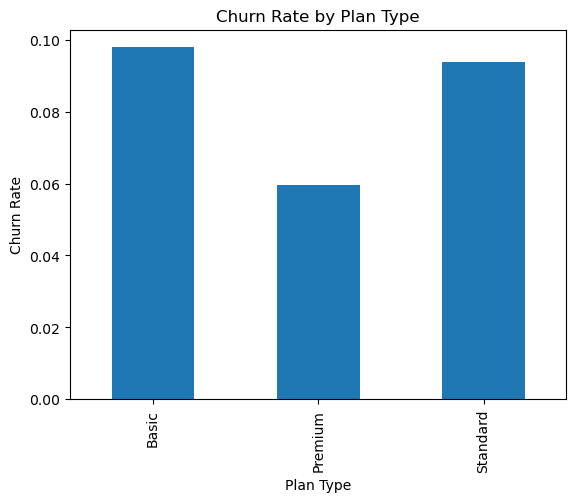

In [20]:
#Churn Rate by Plan Type
churn_plan = df.groupby('Plan_Type')['Churn'].mean()
print(churn_plan)
churn_plan.plot(kind='bar')
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.show()

Region
East     0.109091
North    0.084291
South    0.066421
West     0.096774
Name: Churn, dtype: float64


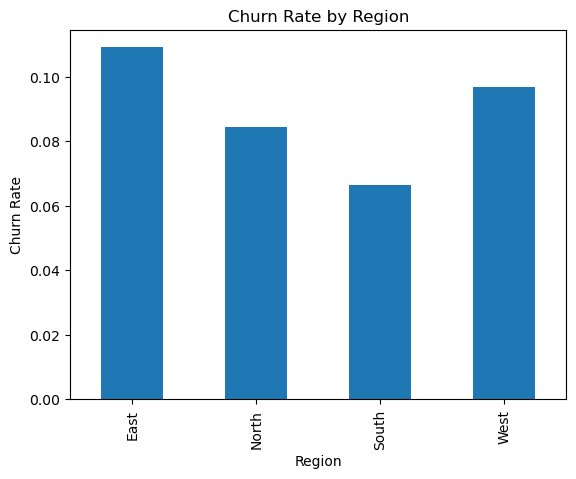

In [21]:
#Churn Rate by Region
churn_region = df.groupby('Region')['Churn'].mean()
print(churn_region)
churn_region.plot(kind='bar')
plt.title('Churn Rate by Region')
plt.xlabel('Region')
plt.ylabel('Churn Rate')
plt.show()

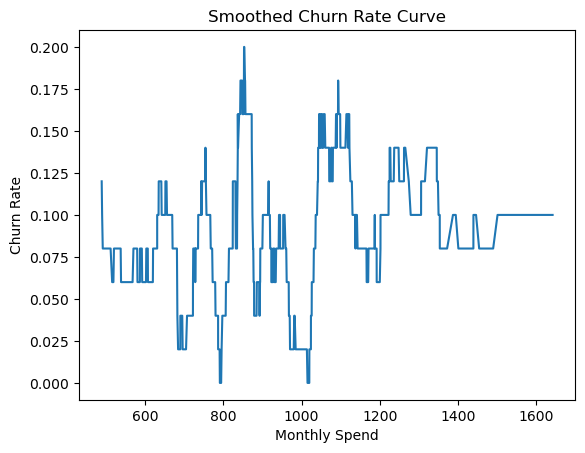

In [22]:
# Sort data
df_sorted = df.sort_values('Monthly_Spend')

# Rolling average
rolling_churn = df_sorted['Churn'].rolling(window=50).mean()

plt.figure()
plt.plot(df_sorted['Monthly_Spend'], rolling_churn)
plt.title('Smoothed Churn Rate Curve')
plt.xlabel('Monthly Spend')
plt.ylabel('Churn Rate')
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [24]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le = LabelEncoder()

for col in ['Contract_Type', 'Plan_Type', 'Auto_Pay', 'Region']:
    df_model[col] = le.fit_transform(df_model[col])

In [25]:
X = df_model.drop([
    'Customer_ID', 
    'Churn',
    'Payment_bin',
    'Spend_bin',
    'Tenure_bin'
], axis=1)

y = df_model['Churn']

In [26]:
print(X.dtypes)

Tenure_Months            int64
Monthly_Spend          float64
Avg_Data_Usage_GB      float64
Usage_Hours            float64
Complaints_Last_6M       int64
Payment_Delay_Days     float64
Support_Calls            int64
Contract_Type            int64
Plan_Type                int64
Auto_Pay                 int64
Discount_Received_%      int64
Internet_Speed_Mbps      int64
Region                   int64
dtype: object


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [30]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.905


In [56]:
pred = lr.predict(X_test)

In [55]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.011340505961034975
RMSE: 0.29154759474226505


In [31]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.915


In [54]:
pred = knn.predict(X_test)

In [32]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:,1]
roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8357080546670543


In [33]:
# New customer data (same order as X.columns)
new_data = [[12, 800, 10, 100, 2, 5, 3, 1, 2, 1, 10, 50, 2]]

# Scale + Predict
prediction = knn.predict(scaler.transform(new_data))

# Result
print("Churn Prediction:", prediction[0])

Churn Prediction: 0


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
# New customer data (same order as X.columns)
new_data = pd.DataFrame([[12, 800, 10, 100, 2, 5, 3, 1, 2, 1, 10, 50, 2]],
                        columns=X.columns)

# Scale + Predict
prediction = lr.predict(scaler.transform(new_data))

print("Churn Prediction:", prediction[0])

Churn Prediction: 0


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [39]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [40]:
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.84


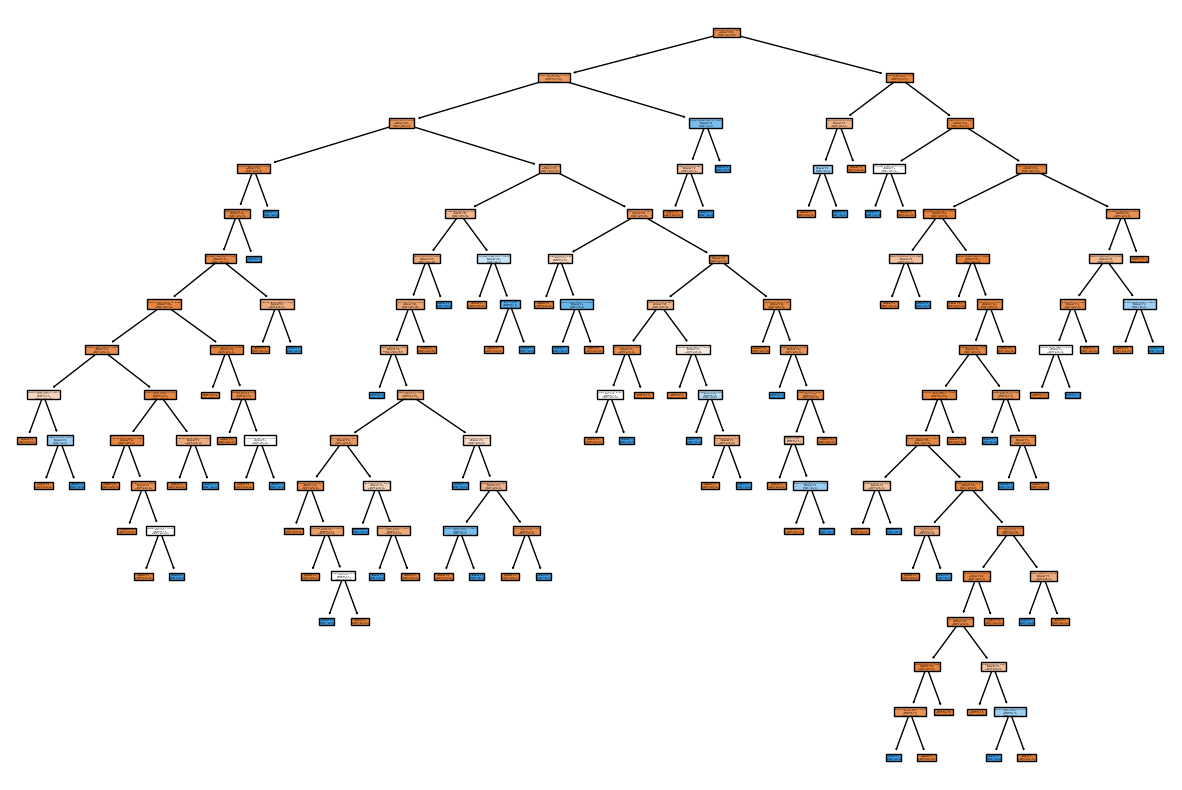

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=['No Churn','Churn'], filled=True)
plt.show()

In [42]:


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

                Feature  Importance
0         Tenure_Months    0.175092
3           Usage_Hours    0.156238
1         Monthly_Spend    0.132811
5    Payment_Delay_Days    0.119415
4    Complaints_Last_6M    0.090053
2     Avg_Data_Usage_GB    0.074397
11  Internet_Speed_Mbps    0.060529
10  Discount_Received_%    0.057831
12               Region    0.048734
7         Contract_Type    0.036814
6         Support_Calls    0.032728
9              Auto_Pay    0.015357
8             Plan_Type    0.000000


In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


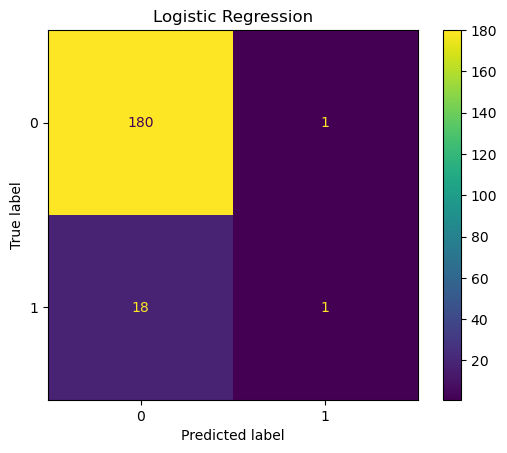

Logistic Regression Metrics:
Precision: 0.5
Recall: 0.05263157894736842
F1 Score: 0.09523809523809523
Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       181
           1       0.50      0.05      0.10        19

    accuracy                           0.91       200
   macro avg       0.70      0.52      0.52       200
weighted avg       0.87      0.91      0.87       200



In [51]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression")
plt.show()

# Metrics
print("Logistic Regression Metrics:")
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("Logistic Regression Report:\n")
print(classification_report(y_test, lr_pred))

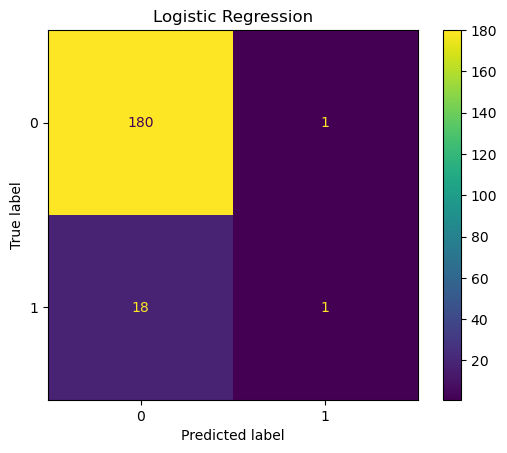

Logistic Regression Metrics:
Precision: 0.5
Recall: 0.05263157894736842
F1 Score: 0.09523809523809523
KNN Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.96       181
           1       1.00      0.11      0.19        19

    accuracy                           0.92       200
   macro avg       0.96      0.55      0.57       200
weighted avg       0.92      0.92      0.88       200



In [52]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression")
plt.show()

# Metrics
print("Logistic Regression Metrics:")
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("KNN Report:\n")
print(classification_report(y_test, knn_pred))

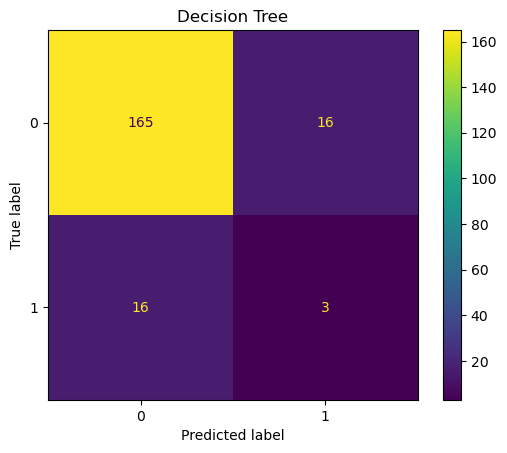

Decision Tree Metrics:
Precision: 0.15789473684210525
Recall: 0.15789473684210525
F1 Score: 0.15789473684210525
Decision Tree Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       181
           1       0.16      0.16      0.16        19

    accuracy                           0.84       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.84      0.84      0.84       200



In [53]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt).plot()
plt.title("Decision Tree")
plt.show()

# Metrics
print("Decision Tree Metrics:")
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("Decision Tree Report:\n")
print(classification_report(y_test, dt_pred))

In [57]:
from sklearn.model_selection import cross_val_score

In [59]:
cv_lr = cross_val_score(lr, X_scaled, y, cv=5, scoring='roc_auc')

print("Logistic Regression CV Scores:", cv_lr)
print("Average CV Score:", cv_lr.mean())

Logistic Regression CV Scores: [0.76952748 0.60527162 0.64377289 0.88461538 0.87118437]
Average CV Score: 0.7548743499081011


In [60]:
cv_knn = cross_val_score(knn, X_scaled, y, cv=5, scoring='roc_auc')

print("KNN CV Scores:", cv_knn)
print("Average CV Score:", cv_knn.mean())

KNN CV Scores: [0.48601736 0.47010608 0.57493895 0.71062271 0.55250305]
Average CV Score: 0.5588376292088926


In [ ]:
cv_dt = cross_val_score(dt, X_scaled, y, cv=5, scoring='roc_auc')

print("Decision Tree CV Scores:", cv_dt)
print("Average CV Score:", cv_dt.mean())



Decision Tree CV Scores: [0.44535519 0.54725169 0.57264957 0.53388278 0.58669109]
Average CV Score: 0.5371660644081088


In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=5, scoring='roc_auc')
grid_lr.fit(X_scaled, y)
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)


Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score: 0.7578857015694046


In [64]:
param_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5, scoring='roc_auc')
grid_knn.fit(X_scaled, y)
print("Best Parameters:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.61468542440095


In [65]:
param_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5, scoring='roc_auc')
grid_dt.fit(X_scaled, y)
print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Score: 0.6244590269903674
